### STARVED V FED

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')


df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})

df = df.sort_values(['file', 'track_id', 'rel_frame'])



metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']


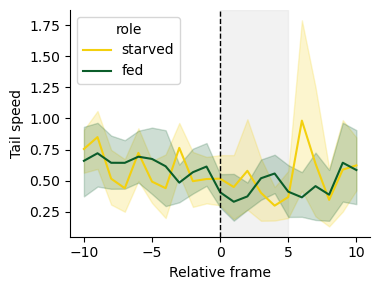

In [3]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='role',
    hue_order=['starved', 'fed'],
    palette={'starved': "#F3D00E", 'fed': '#0B5D2A'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-starved/speed.pdf', format='pdf')
plt.show()


In [4]:
# Frames 1-5: average tail speed per larva, then paired fed vs starved test


speed_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(1, 5)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = wilcoxon(speed_1_5['starved'], speed_1_5['fed'])
print(f"Wilcoxon paired test, frames 1-5, starved vs fed: W={stat:.3g}, p={p:.3g}")


role,fed,starved
file,,
2026-04-28_12-17-10_td5.tracks.feather,0.311840,0.456355
2026-05-11_11-19-24_td4.tracks.feather,0.703004,0.484533
2026-05-12_14-44-29_td4.tracks.feather,0.299530,0.575512
2026-05-19_12-25-59_td17.tracks.feather,0.331484,0.228499
2026-06-22_11-57-42_td4.tracks.feather,0.377118,0.662264
2026-06-22_11-59-31_td5.tracks.feather,0.416257,0.071307
2026-06-23_15-48-53_td5.tracks.feather,0.629456,0.457978


role
fed        0.438384
starved    0.419493
dtype: float64
Wilcoxon paired test, frames 1-5, starved vs fed: W=13, p=0.938


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_58774/3065523722.py:36: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


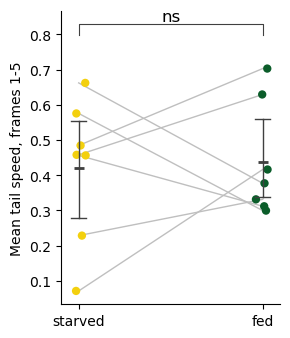

In [5]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in speed_1_5.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=speed_1_5_plot,
    x='role',
    y='speed_tail',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='role',
    y='speed_tail',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y = ymax + (ymax - ymin) * 0.15
h = (ymax - ymin) * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-starved/speed_mean.pdf', format='pdf')
plt.show()


In [6]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(-5, -1)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(1, 5)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

stat, p = wilcoxon(pre_speed_1_5['starved'], post_speed_1_5['starved'])
print(f"Starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p:.3g}")

stat, p = wilcoxon(pre_speed_1_5['fed'], post_speed_1_5['fed'])
print(f"Fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p:.3g}")

stat, p = wilcoxon(change_speed_1_5['starved'], change_speed_1_5['fed'])
print(f"Change score, tail speed starved vs fed, frames 1-5: W={stat:.3g}, p={p:.3g}")


pre                post  \
role                                          fed   starved       fed   
file                                                                    
2026-04-28_12-17-10_td5.tracks.feather   0.234589  0.496749  0.311840   
2026-05-11_11-19-24_td4.tracks.feather   0.676575  0.578848  0.703004   
2026-05-12_14-44-29_td4.tracks.feather   0.778907  0.645438  0.299530   
2026-05-19_12-25-59_td17.tracks.feather  0.490206  0.825529  0.331484   
2026-06-22_11-57-42_td4.tracks.feather   0.901595  0.620144  0.377118   
2026-06-22_11-59-31_td5.tracks.feather   0.748890  0.142290  0.416257   
2026-06-23_15-48-53_td5.tracks.feather   0.306083  0.476297  0.629456   

                                                  post_minus_pre            
role                                      starved            fed   starved  
file                                                                        
2026-04-28_12-17-10_td5.tracks.feather   0.456355       0.077251 -0.040395  
2026-05-11_11-19-24_td4.tracks.feather   0.484533       0.026429 -0.094315  
2026-05-12_14-44-29_td4.tracks.feather   0.575512      -0.479378 -0.069926  
2026-05-19_12-25-59_td17.tracks.feather  0.228499      -0.158722 -0.597030  
2026-06-22_11-57-42_td4.tracks.feather   0.662264      -0.524477  0.042121  
2026-06-22_11-59-31_td5.tracks.feather   0.071307      -0.332633 -0.070983  
2026-06-23_15-48-53_td5.tracks.feather   0.457978       0.323373 -0.018319

Mean pre:
role
fed        0.590978
starved    0.540757
dtype: float64

Mean post:
role
fed        0.438384
starved    0.419493
dtype: float64

Mean post - pre:
role
fed       -0.152594
starved   -0.121264
dtype: float64
Starved pre vs post, tail speed frames 1-5: W=3, p=0.0781
Fed pre vs post, tail speed frames 1-5: W=7, p=0.297
Change score, tail speed starved vs fed, frames 1-5: W=13, p=0.938


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_58774/1077175783.py:38: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


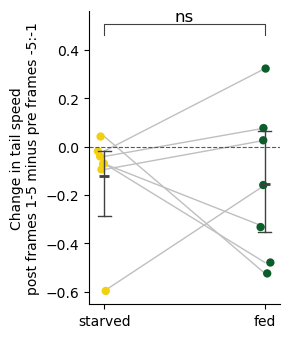

In [7]:
# Plot the values used in the frames 1-5 speed change-score test
_, change_p = wilcoxon(change_speed_1_5['starved'], change_speed_1_5['fed'])

change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in change_speed_1_5.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=change_speed_1_5_plot,
    x='role',
    y='speed_change',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='role',
    y='speed_change',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y = ymax + (ymax - ymin) * 0.15
h = (ymax - ymin) * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-starved/speed_baseline_change.pdf', format='pdf')
plt.show()


In [8]:
# Test whether each condition changes from before to after contact, frames 1-5
stat, p_starved = wilcoxon(pre_speed_1_5['starved'], post_speed_1_5['starved'])
print(f"Starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved:.3g}")
print(f"Starved mean change: {change_speed_1_5['starved'].mean():.3g}")

stat, p_fed = wilcoxon(pre_speed_1_5['fed'], post_speed_1_5['fed'])
print(f"Fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed:.3g}")
print(f"Fed mean change: {change_speed_1_5['fed'].mean():.3g}")


Starved pre vs post, tail speed frames 1-5: W=3, p=0.0781
Starved mean change: -0.121
Fed pre vs post, tail speed frames 1-5: W=7, p=0.297
Fed mean change: -0.153


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_58774/1234231808.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_58774/1234231808.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


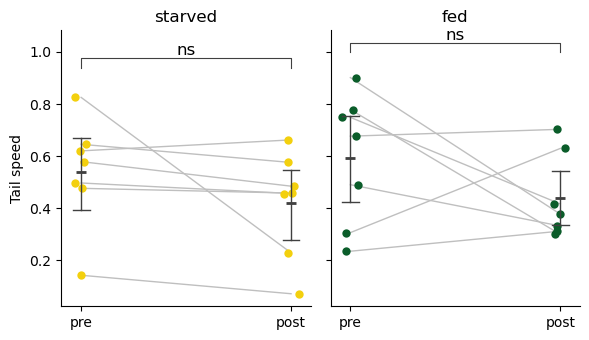

In [9]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, role, color, test_p in zip(
    axes,
    ['starved', 'fed'],
    ['#F3D00E', '#0B5D2A'],
    [p_starved, p_fed]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[role],
        'post': post_speed_1_5[role]
    })
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y = ymax + (ymax - ymin) * 0.15
    h = (ymax - ymin) * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(role)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if role == 'starved' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-starved/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [10]:
# Frames 1-10: average tail speed per larva, then paired fed vs starved test
speed_1_10 = (
    first_interaction[first_interaction['rel_frame'].between(1, 10)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = wilcoxon(speed_1_10['starved'], speed_1_10['fed'])
print(f"Wilcoxon paired test, frames 1-10, starved vs fed: W={stat:.3g}, p={p:.3g}")


role,fed,starved
file,,
2026-04-28_12-17-10_td5.tracks.feather,0.440079,0.334330
2026-05-11_11-19-24_td4.tracks.feather,0.707107,1.123556
2026-05-12_14-44-29_td4.tracks.feather,0.239194,0.527475
2026-05-19_12-25-59_td17.tracks.feather,0.490024,0.534560
2026-06-22_11-57-42_td4.tracks.feather,0.302729,0.596429
2026-06-22_11-59-31_td5.tracks.feather,0.570890,0.132036
2026-06-23_15-48-53_td5.tracks.feather,0.491434,0.442683


role
fed        0.463065
starved    0.527296
dtype: float64
Wilcoxon paired test, frames 1-10, starved vs fed: W=12, p=0.812


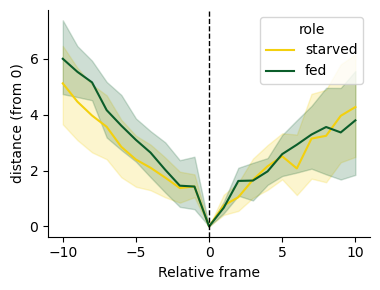

In [11]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='role',
    hue_order=['starved', 'fed'],
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-starved/distance_from_0.pdf', format='pdf')
plt.show()


In [12]:
# Frames 1-5: average distance_from_0 per larva, then paired fed vs starved test
distance_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(1, 5)]
    .groupby(['file', 'role'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = wilcoxon(distance_1_5['starved'], distance_1_5['fed'])
print(f"Wilcoxon paired test, distance_from_0 frames 1-5, starved vs fed: W={stat:.3g}, p={p:.3g}")


role,fed,starved
file,,
2026-04-28_12-17-10_td5.tracks.feather,2.101817,1.599526
2026-05-11_11-19-24_td4.tracks.feather,2.351170,1.804506
2026-05-12_14-44-29_td4.tracks.feather,0.564930,3.086688
2026-05-19_12-25-59_td17.tracks.feather,1.499380,1.984690
2026-06-22_11-57-42_td4.tracks.feather,1.223125,1.600497
2026-06-22_11-59-31_td5.tracks.feather,2.489517,0.343474
2026-06-23_15-48-53_td5.tracks.feather,1.674872,0.974056


role
fed        1.700687
starved    1.627634
dtype: float64
Wilcoxon paired test, distance_from_0 frames 1-5, starved vs fed: W=10, p=0.578


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_58774/2677357591.py:38: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


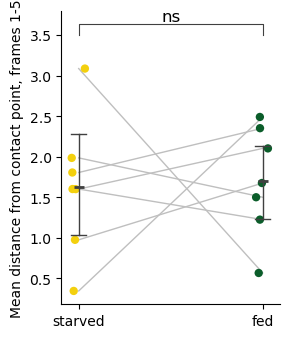

In [13]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = wilcoxon(distance_1_5['starved'], distance_1_5['fed'])

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in distance_1_5.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=distance_1_5_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y = ymax + (ymax - ymin) * 0.15
h = (ymax - ymin) * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


role,fed,starved
file,,
2026-04-28_12-17-10_td5.tracks.feather,3.450078,2.091278
2026-05-11_11-19-24_td4.tracks.feather,3.587398,3.799417
2026-05-12_14-44-29_td4.tracks.feather,0.477309,4.112341
2026-05-19_12-25-59_td17.tracks.feather,3.167297,3.917158
2026-06-22_11-57-42_td4.tracks.feather,1.061781,1.546483
2026-06-22_11-59-31_td5.tracks.feather,3.322546,0.416685
2026-06-23_15-48-53_td5.tracks.feather,2.748868,1.510067


role
fed        2.545040
starved    2.484776
dtype: float64
Wilcoxon paired test, distance_from_0 frames 1-10, starved vs fed: W=13, p=0.938


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_58774/3922893810.py:50: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


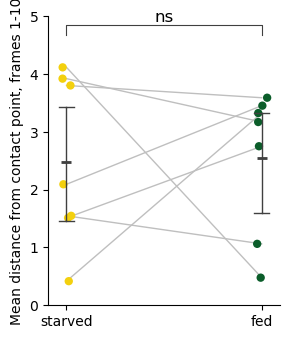

In [15]:
# Frames 1-10: average distance_from_0 per larva, then paired fed vs starved test
distance_1_10 = (
    first_interaction[first_interaction['rel_frame'].between(1, 10)]
    .groupby(['file', 'role'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = wilcoxon(distance_1_10['starved'], distance_1_10['fed'])
print(f"Wilcoxon paired test, distance_from_0 frames 1-10, starved vs fed: W={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in distance_1_10.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=distance_1_10_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 5)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-starved/distance_from_0_mean.pdf', format='pdf')
plt.show()
